In [2]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import matplotlib.pyplot as plt

crash_df = pd.read_csv(r'C:\DATA ANALYSIS AND DATA SCIENCE PROJECTS\Accident Severity Prediction\data\clean data\final_dataset.csv')
crash_df['Fatality_Level'] = crash_df['Fatalities_Count'].apply(lambda x: 'High' if x > 1 else 'Low')
gdf = gpd.GeoDataFrame(crash_df, geometry=gpd.points_from_xy(crash_df.Longitude, crash_df.Latitude), crs="EPSG:4326")
states_gdf = gpd.read_file(r'C:\DATA ANALYSIS AND DATA SCIENCE PROJECTS\Accident Severity Prediction\data\clean data\cb_2023_us_state_20m\cb_2023_us_state_20m.shp')

In [3]:
states_gdf.head(1)

,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,48,01779801,0400000US48,48,TX,Texas,00,676686238592,18982083586,"POLYGON ((-106.62344 31.91403, -106.63011 31.9..."


In [4]:
fatalities_by_state = (
    crash_df.groupby('State_Name').agg(
        Total_Fatalities=('Total_Killed', 'sum'),
        Average_Fatalities=('Total_Killed', 'mean'),
        Crash_Count=('Crash_ID', 'count')   
    )
    .reset_index()
)

merged = states_gdf.merge(
    fatalities_by_state,
    how="left",
    left_on="NAME",        
    right_on="State_Name"
)

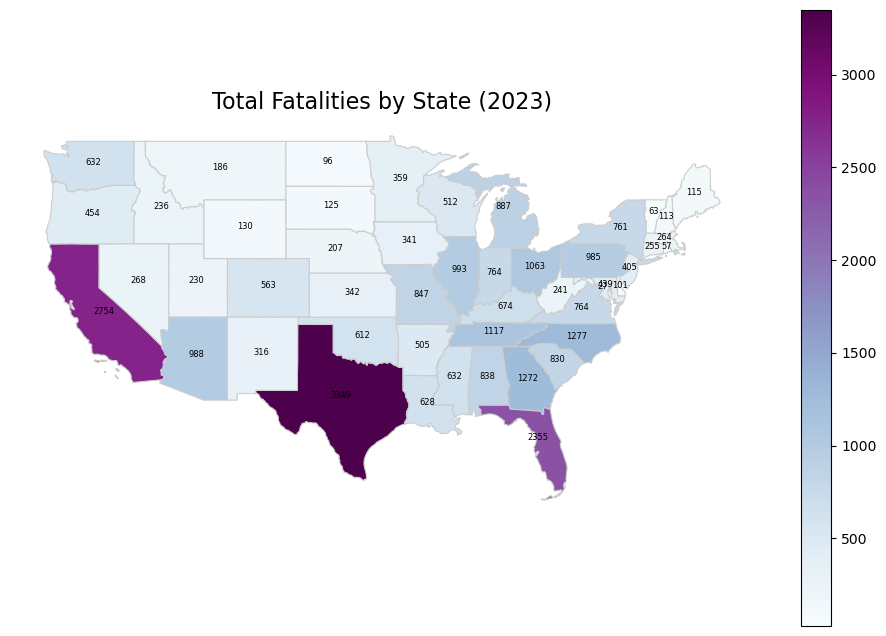

In [5]:
#Total Fatalities
mainland = merged[~merged["STUSPS"].isin(["AK", "HI", "PR", "GU", "VI", "MP", "AS"])]

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
mainland.plot(
    column="Total_Fatalities",
    cmap="BuPu",          
    linewidth=0.8,
    edgecolor="0.8",
    legend=True,
    ax=ax,
)
ax.set_title("Total Fatalities by State (2023)", fontsize=16)
ax.axis("off")

for idx, row in mainland.iterrows():
    plt.annotate(
        text=f"{int(row['Total_Fatalities'])}",  
        xy=(row["geometry"].centroid.x, row["geometry"].centroid.y),
        horizontalalignment="center",
        fontsize=6,
        color="black"
    )

plt.show()

In [5]:
top5 = mainland.nlargest(5, "Total_Fatalities")[["State_Name", "Total_Fatalities"]].reset_index(drop=True)
bottom5 = mainland.nsmallest(5, "Total_Fatalities")[["State_Name", "Total_Fatalities"]].reset_index(drop=True)

print("States with Highest Total Fatalities:")
display(top5)

total_fatalities_nationwide = mainland["Total_Fatalities"].sum()
top5_fatalities = top5["Total_Fatalities"].sum()
percentage = (top5_fatalities / total_fatalities_nationwide) * 100
print(f"\nTop 5 states account for {percentage:.2f}% of total fatalities nationwide.")

print("\n States with Lowest Total Fatalities:")
display(bottom5)

total_fatalities_nationwide = mainland["Total_Fatalities"].sum()
bottom5 = mainland.nsmallest(5, "Total_Fatalities")[["State_Name", "Total_Fatalities"]]
bottom5_fatalities = bottom5["Total_Fatalities"].sum()
bottom_percentage = (bottom5_fatalities / total_fatalities_nationwide) * 100
print(f"Bottom 5 states account for {bottom_percentage:.2f}% of total fatalities nationwide.")

print("\nThis pattern indicates that high-population, high-traffic states contribute most to national crash deaths.")
print("On the other hand, sparsely populated northern states record fewer than 200 fatalities annually.")


States with Highest Total Fatalities:


,State_Name,Total_Fatalities
0,Texas,3349.0
1,California,2754.0
2,Florida,2355.0
3,North Carolina,1277.0
4,Georgia,1272.0



Top 5 states account for 34.43% of total fatalities nationwide.

 States with Lowest Total Fatalities:


,State_Name,Total_Fatalities
0,District of Columbia,27.0
1,Rhode Island,57.0
2,Vermont,63.0
3,North Dakota,96.0
4,Delaware,101.0


Bottom 5 states account for 1.08% of total fatalities nationwide.

This pattern indicates that high-population, high-traffic states contribute most to national crash deaths.
On the other hand, sparsely populated northern states record fewer than 200 fatalities annually.


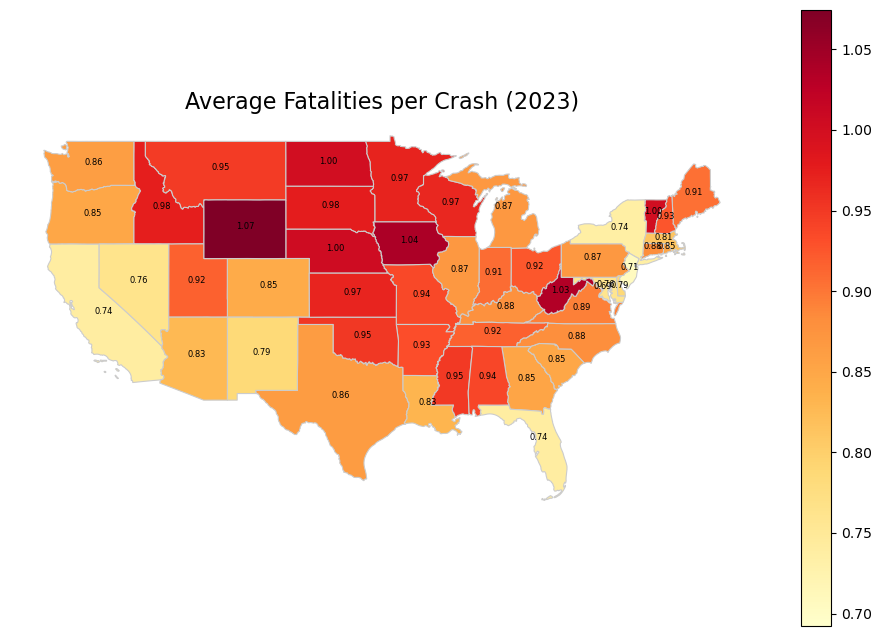

In [6]:
#Average Fatalities
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

mainland.plot(
    column="Average_Fatalities",
    cmap="YlOrRd",
    linewidth=0.8,
    edgecolor="0.8",
    legend=True,
    ax=ax,
)

ax.set_title("Average Fatalities per Crash (2023)", fontsize=16)
ax.axis("off")

for idx, row in mainland.iterrows():
    value = row["Average_Fatalities"]
    if pd.notnull(value):  
        plt.annotate(
            text=f"{value:.2f}",  
            xy=(row["geometry"].centroid.x, row["geometry"].centroid.y),
            horizontalalignment="center",
            fontsize=6,
            color="black"
        )


plt.show()


In [7]:
top5_avg = mainland.nlargest(5, "Average_Fatalities")[["State_Name", "Average_Fatalities"]].reset_index(drop=True)
bottom5_avg = mainland.nsmallest(5, "Average_Fatalities")[["State_Name", "Average_Fatalities"]].reset_index(drop=True)

national_avg = mainland["Average_Fatalities"].mean()
print(f"\nNational average fatalities per crash: {national_avg:.3f}\n")

print("States with Highest Average Fatalities per Crash:")
display(top5_avg)
top5_avg_value = top5_avg["Average_Fatalities"].mean()
print(f"Top 5 states average fatalities per crash: {top5_avg_value:.3f}")

bottom5_avg_value = bottom5_avg["Average_Fatalities"].mean()
print("\nStates with Lowest Average Fatalities per Crash:")
display(bottom5_avg)
print(f"Bottom 5 states average fatalities per crash: {bottom5_avg_value:.3f}")

print("\nThis highlights that while some states experience fewer crashes overall,")
print("the severity can be significantly higher; often in more rural or remote regions.")
print("States with lower averages likely benefit from better emergency services and road safety infrastructure, ")
print("despite very high total crashes.")



National average fatalities per crash: 0.887

States with Highest Average Fatalities per Crash:


,State_Name,Average_Fatalities
0,Wyoming,1.074380
1,Iowa,1.039634
2,West Virginia,1.034335
3,Nebraska,1.004854
4,North Dakota,1.000000


Top 5 states average fatalities per crash: 1.031

States with Lowest Average Fatalities per Crash:


,State_Name,Average_Fatalities
0,District of Columbia,0.692308
1,New Jersey,0.706806
2,New York,0.736689
3,California,0.738932
4,Florida,0.739868


Bottom 5 states average fatalities per crash: 0.723

This highlights that while some states experience fewer crashes overall,
the severity can be significantly higher; often in more rural or remote regions.
States with lower averages likely benefit from better emergency services and road safety infrastructure, 
despite very high total crashes.


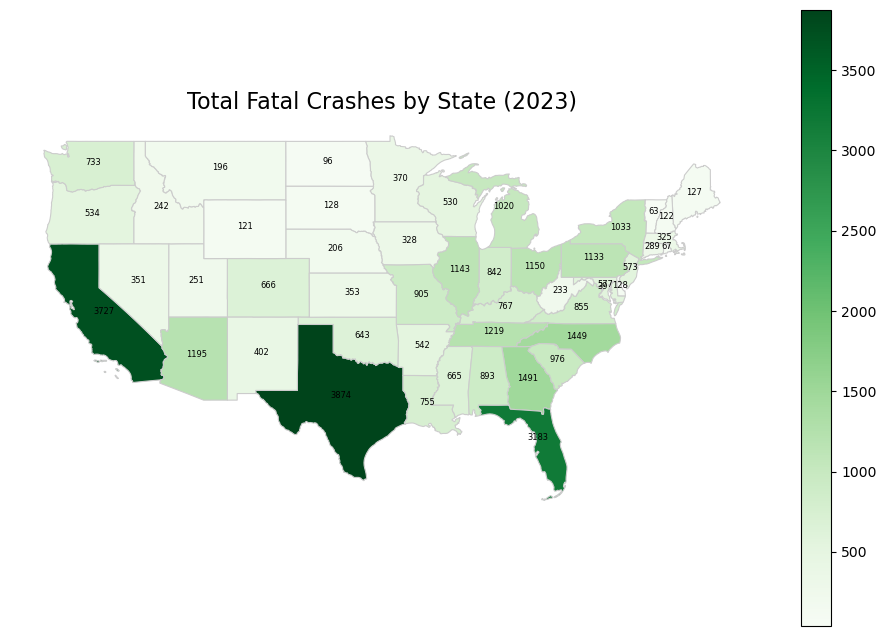

In [8]:
#Total Fatal Crashes
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

mainland.plot(
    column="Crash_Count",
    cmap="Greens",     
    linewidth=0.8,
    edgecolor="0.8",
    legend=True,
    ax=ax,
)

ax.set_title("Total Fatal Crashes by State (2023)", fontsize=16)
ax.axis("off")

for idx, row in mainland.iterrows():
    plt.annotate(
        text=f"{int(row['Crash_Count'])}",  
        xy=(row["geometry"].centroid.x, row["geometry"].centroid.y),
        horizontalalignment="center",
        fontsize=6,
        color="black"
    )

plt.show()

In [9]:
top5_crashes = mainland.nlargest(5, "Crash_Count")[["State_Name", "Crash_Count"]].reset_index(drop=True)
bottom5_crashes = mainland.nsmallest(5, "Crash_Count")[["State_Name", "Crash_Count"]].reset_index(drop=True)
total_crashes_nationwide = mainland["Crash_Count"].sum()

print("States with Highest Total Crash Counts:")
display(top5_crashes)

top5_crashes_total = top5_crashes["Crash_Count"].sum()
crash_percentage = (top5_crashes_total / total_crashes_nationwide) * 100
print(f"\nTop 5 states account for {crash_percentage:.2f}% of total crashes nationwide.")

print("\nStates with Lowest Total Crash Counts:")
display(bottom5_crashes)

bottom5_crashes_total = bottom5_crashes["Crash_Count"].sum()
bottom_crash_percentage = (bottom5_crashes_total / total_crashes_nationwide) * 100
print(f"Bottom 5 states account for {bottom_crash_percentage:.2f}% of total crashes nationwide.")

print("\nThis distribution shows that states with high crash volumes, such as Texas and California,")
print("correspondingly experience higher total fatalities, emphasizing the relationship between exposure and risk.")
print("However, comparing crash counts with average fatalities can reveal where crashes tend to be deadlier rather than more frequent.")


States with Highest Total Crash Counts:


,State_Name,Crash_Count
0,Texas,3874.0
1,California,3727.0
2,Florida,3183.0
3,Georgia,1491.0
4,North Carolina,1449.0



Top 5 states account for 36.59% of total crashes nationwide.

States with Lowest Total Crash Counts:


,State_Name,Crash_Count
0,District of Columbia,39.0
1,Vermont,63.0
2,Rhode Island,67.0
3,North Dakota,96.0
4,Wyoming,121.0


Bottom 5 states account for 1.03% of total crashes nationwide.

This distribution shows that states with high crash volumes, such as Texas and California,
correspondingly experience higher total fatalities, emphasizing the relationship between exposure and risk.
However, comparing crash counts with average fatalities can reveal where crashes tend to be deadlier rather than more frequent.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv(r"C:\DATA ANALYSIS AND DATA SCIENCE PROJECTS\Accident Severity Prediction\data\clean data\final_dataset.csv")

In [6]:
data.columns

Index(['Unnamed: 0', 'State_Code', 'State_Name', 'Crash_ID',
       'Count_Non_Motorists', 'Count_Vehicles_Total', 'Count_Vehicle_Forms',
       'Count_PVH_Involved', 'Count_Occupants_MV', 'City_Name', 'Month_Name',
       'Day_of_Month', 'Day_of_Week', 'Crash_Hour', 'Crash_Minute',
       'Area_Rural_Urban', 'Road_Functional_Class', 'On_NHS_Road', 'Latitude',
       'Longitude', 'Intersection_Type', 'Light_Condition',
       'Weather_Condition', 'Notif_Hour', 'Notif_Minute', 'Arrival_Hour',
       'Arrival_Minute', 'Hospital_Hour', 'Hospital_Minute',
       'Fatalities_Count', 'Clean_Light_Condition', 'Clean_Weather_Condition',
       'Total_Killed', 'Total_Alive', 'Fatal_Seats_List',
       'Killed_Restraint_List', 'Any_Driver_Drinking',
       'Total_Drinking_Drivers', 'Driver_License_Category',
       'Driver_Max_Prev_Accident_Count', 'Driver_Max_Prev_Speeding_Count',
       'Max_Driver_Age', 'Min_Driver_Age', 'Driver_Sex_List',
       'Total_Exceeding_Limit_Vehicles', 'Total_Too_F

C:\Users\Hp\AppData\Local\Temp\ipykernel_20588\3107100273.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agg_road_rate.values, y=agg_road_rate.index, palette='inferno')


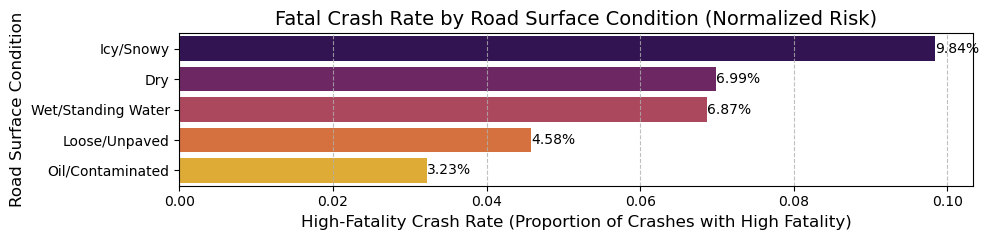

In [12]:
#Fatal Crash Rate vs Road Surface Conditions
#Basically if there are total 100 crashes in dry road then our graph shows what percent of them are high fatality 
data['_is_fatal'] = data['Fatalities_Count'].apply(lambda x: 1 if x >= 2 else 0)
agg_road_rate = data.groupby('Crash_Road_Surface_Condition')['_is_fatal'].mean().sort_values(ascending=False)
total_conditions = agg_road_rate.shape[0]
plt.figure(figsize=(10, total_conditions * 0.5)) 
sns.barplot(x=agg_road_rate.values, y=agg_road_rate.index, palette='inferno')
plt.xlabel("High-Fatality Crash Rate (Proportion of Crashes with High Fatality)", fontsize=12)
plt.ylabel("Road Surface Condition", fontsize=12)
plt.title("Fatal Crash Rate by Road Surface Condition (Normalized Risk)", fontsize=14)
for index, value in enumerate(agg_road_rate.values):
    label = f'{value*100:.2f}%'
    plt.text(value, index, label, va='center', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_20588\3218967646.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agg_weather_rate.values, y=agg_weather_rate.index, palette='viridis')


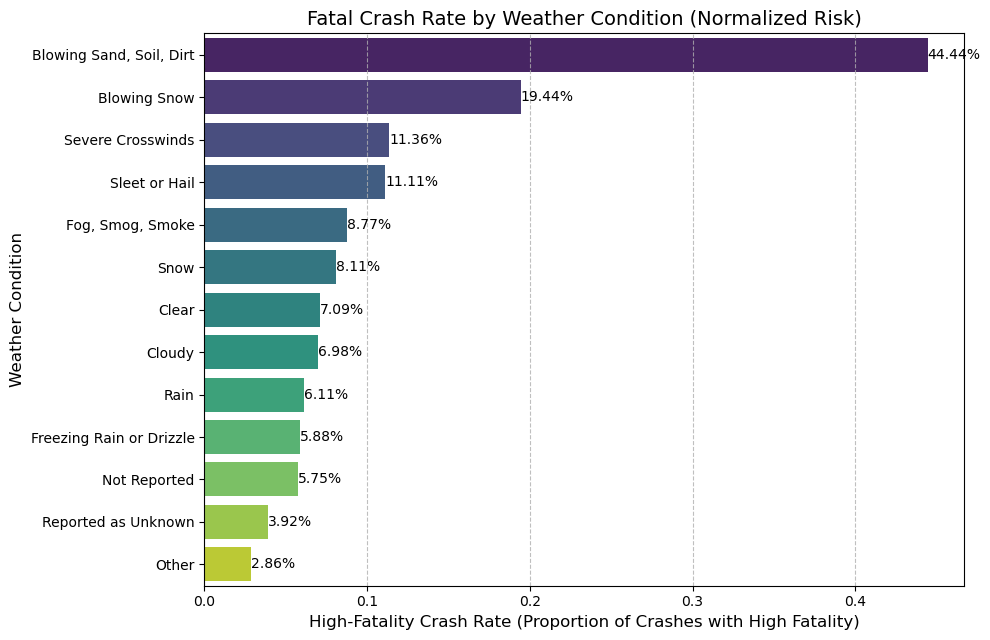

In [13]:
#Fatal Crash Rate vs Weather Conditions
#Basically if there are total 100 crashes in clear weather then our graph shows what percent of them are high fatality 
data['_is_fatal'] = data['Fatalities_Count'].apply(lambda x: 1 if x >= 2 else 0)
agg_weather_rate = data.groupby('Weather_Condition')['_is_fatal'].mean().sort_values(ascending=False)
total_conditions = agg_weather_rate.shape[0]
plt.figure(figsize=(10, total_conditions * 0.5)) 
sns.barplot(x=agg_weather_rate.values, y=agg_weather_rate.index, palette='viridis')
plt.xlabel("High-Fatality Crash Rate (Proportion of Crashes with High Fatality)", fontsize=12)
plt.ylabel("Weather Condition", fontsize=12)
plt.title("Fatal Crash Rate by Weather Condition (Normalized Risk)", fontsize=14)
for index, value in enumerate(agg_weather_rate.values):
    label = f'{value*100:.2f}%'
    plt.text(value, index, label, va='center', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_20588\2902221212.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=hour_data.index, y=hour_data.values, palette='rocket')


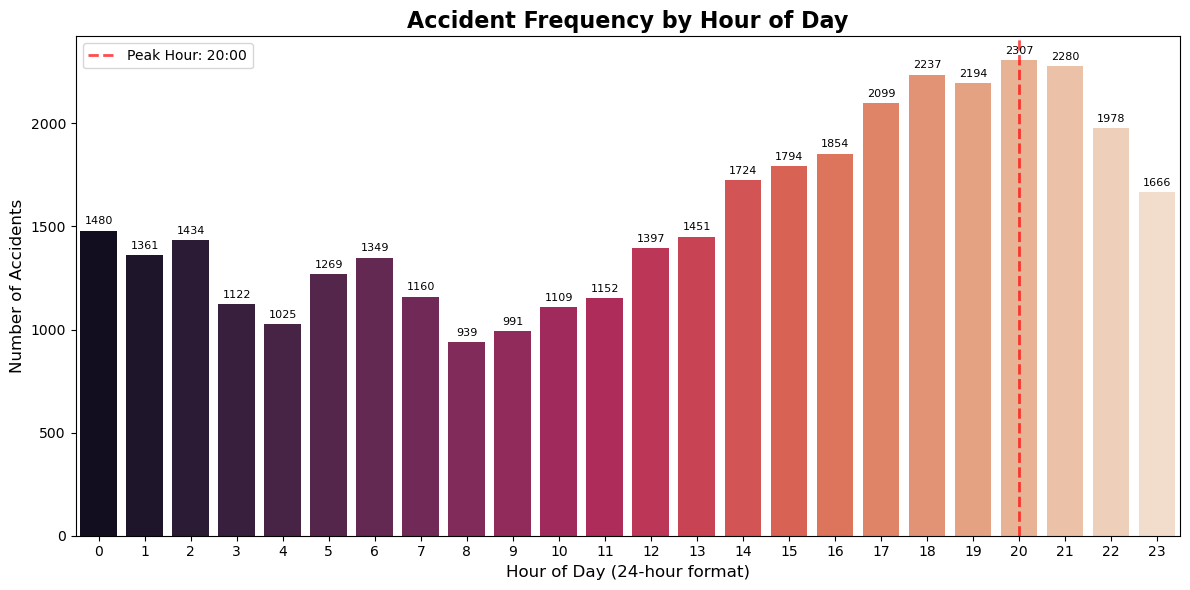

Peak accident hour: 20:00 with 2307 accidents
Lowest accident hour: 8:00 with 939 accidents


In [14]:
hour_data = data[data['Crash_Hour'] < 24]['Crash_Hour'].value_counts().sort_index()
plt.figure(figsize=(12,6))
ax = sns.barplot(x=hour_data.index, y=hour_data.values, palette='rocket')
plt.title('Accident Frequency by Hour of Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day (24-hour format)', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
for i, v in enumerate(hour_data.values):
    ax.text(i, v + 20, str(v), ha='center', va='bottom', fontsize=8) 
peak_hour = hour_data.idxmax()
plt.axvline(x=peak_hour, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Peak Hour: {peak_hour}:00')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Peak accident hour: {peak_hour}:00 with {hour_data.max()} accidents")
print(f"Lowest accident hour: {hour_data.idxmin()}:00 with {hour_data.min()} accidents")


C:\Users\Hp\AppData\Local\Temp\ipykernel_20588\900203497.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=day_counts.index, y=day_counts.values, palette=colors)


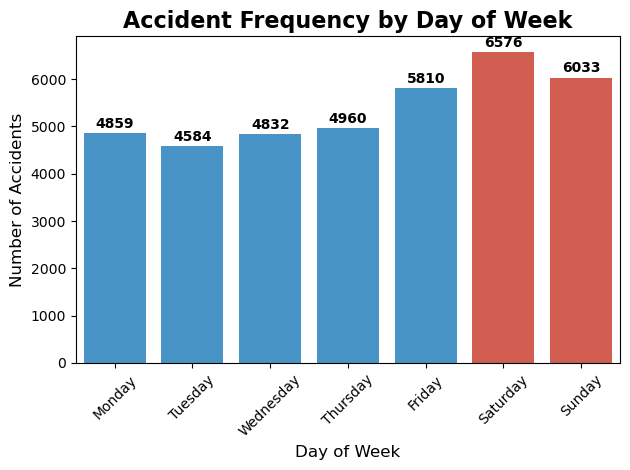

Highest accident day: Saturday with 6576 accidents
Lowest accident day: Tuesday with 4584 accidents


In [16]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = data['Day_of_Week'].value_counts().reindex(day_order)
colors = ['#3498db' if day in day_order[:5] else '#e74c3c' for day in day_order]
ax = sns.barplot(x=day_counts.index, y=day_counts.values, palette=colors)
plt.title('Accident Frequency by Day of Week', fontsize=16, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45)
for i, v in enumerate(day_counts.values):
    ax.text(i, v + 50, str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Highest accident day: {day_counts.idxmax()} with {day_counts.max()} accidents")
print(f"Lowest accident day: {day_counts.idxmin()} with {day_counts.min()} accidents")

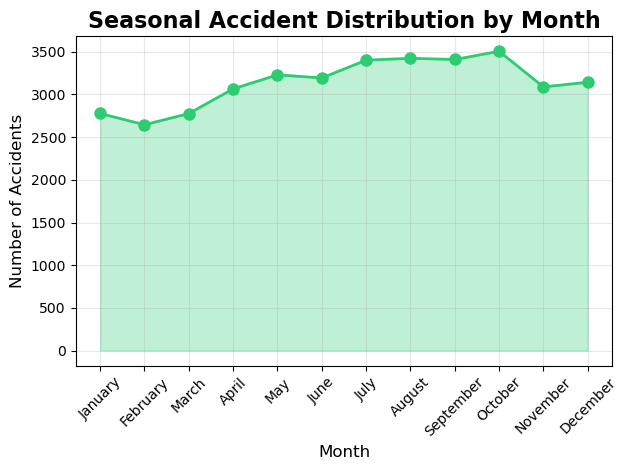

Peak accident month: October with 3505 accidents


In [ ]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
month_counts = data['Month_Name'].value_counts().reindex(month_order)
plt.plot(month_order, month_counts.values, marker='o', linewidth=2, markersize=8, color='#2ecc71')
plt.fill_between(range(len(month_order)), month_counts.values, alpha=0.3, color='#2ecc71')
plt.title('Seasonal Accident Distribution by Month', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
peak_month_idx = month_counts.idxmax()
peak_month_pos = month_order.index(peak_month_idx)
plt.tight_layout()
plt.show()
print(f"Peak accident month: {peak_month_idx} with {month_counts.max()} accidents")

C:\Users\Hp\AppData\Local\Temp\ipykernel_11644\1507540256.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=road_counts.index, y=road_counts.values, palette='magma')


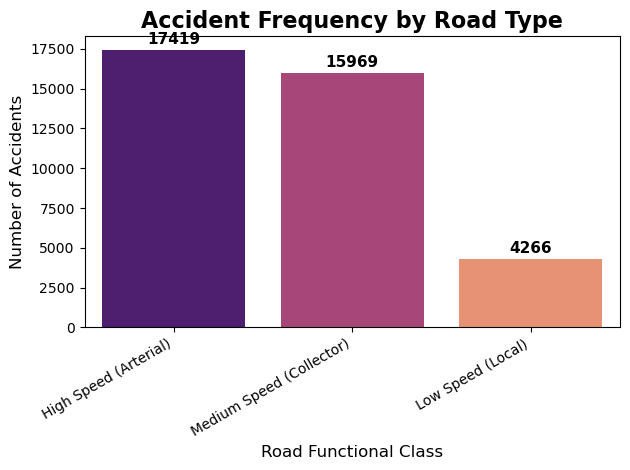

Most accident-prone road type: High Speed (Arterial)


In [12]:
# Road functional classes 
road_counts = data['Road_Functional_Class'].value_counts()
ax = sns.barplot(x=road_counts.index, y=road_counts.values, palette='magma')
plt.title('Accident Frequency by Road Type', fontsize=16, fontweight='bold')
plt.xlabel('Road Functional Class', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(road_counts.values):
    ax.text(i, v + 200, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Most accident-prone road type: {road_counts.idxmax()}")

C:\Users\Hp\AppData\Local\Temp\ipykernel_11644\926607064.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agg_road_rate.values, y=agg_road_rate.index, palette='magma')


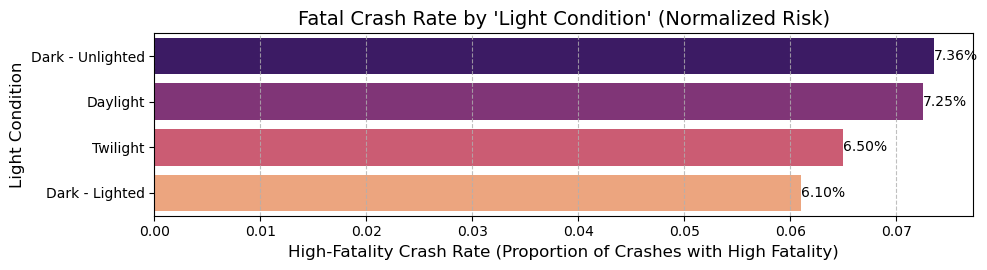

In [13]:
#Fatal Crash Rate vs Light Conditions 
data['_is_fatal'] = data['Fatalities_Count'].apply(lambda x: 1 if x >= 2 else 0)
agg_road_rate = data.groupby('Clean_Light_Condition')['_is_fatal'].mean().sort_values(ascending=False)
total_conditions = agg_road_rate.shape[0]
plt.figure(figsize=(10, total_conditions * 0.7)) 
sns.barplot(x=agg_road_rate.values, y=agg_road_rate.index, palette='magma')
plt.xlabel("High-Fatality Crash Rate (Proportion of Crashes with High Fatality)", fontsize=12)
plt.ylabel('Light Condition', fontsize=12)
plt.title("Fatal Crash Rate by 'Light Condition' (Normalized Risk)", fontsize=14)
for index, value in enumerate(agg_road_rate.values):
    label = f'{value*100:.2f}%'
    plt.text(value, index, label, va='center', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()

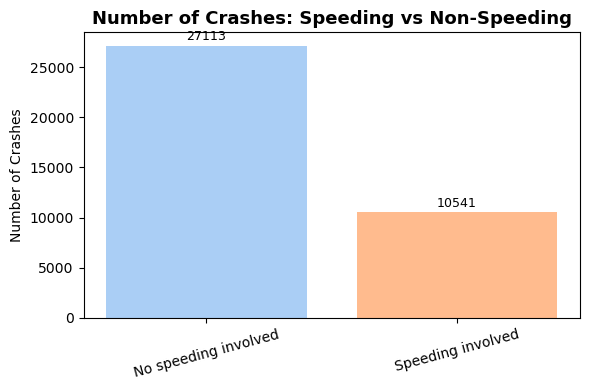

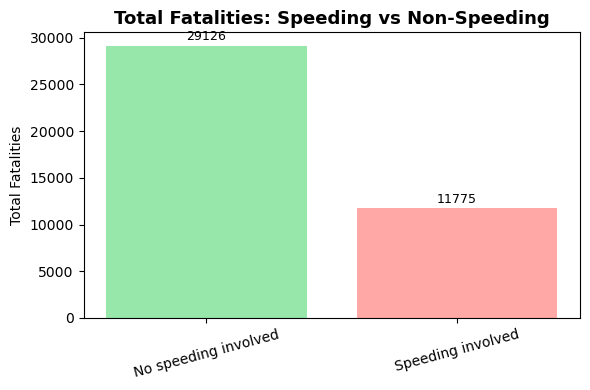

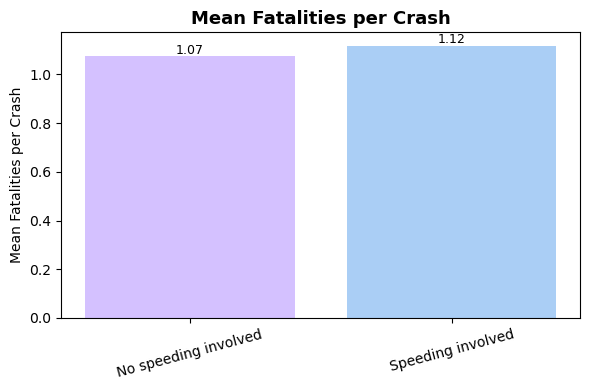

Summary table:


,label,crashes,total_fatalities,mean_fatalities,fatalities_per_100_crashes
0,No speeding involved,27113,29126,1.074245,107.424483
1,Speeding involved,10541,11775,1.117067,111.706669


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

col_exc = "Total_Exceeding_Limit_Vehicles"
col_tf  = "Total_Too_Fast_Vehicles"
col_fatal = "Fatalities_Count"

df = data[[col_exc, col_tf, col_fatal]].copy()
df[col_exc] = pd.to_numeric(df[col_exc], errors='coerce').fillna(0).astype(int)
df[col_tf]  = pd.to_numeric(df[col_tf],  errors='coerce').fillna(0).astype(int)
df[col_fatal] = pd.to_numeric(df[col_fatal], errors='coerce').fillna(0).astype(int)

df['speeding_involved'] = (df[col_exc] > 0) | (df[col_tf] > 0)
agg = df.groupby('speeding_involved').agg(
    crashes = (col_fatal, 'size'),
    total_fatalities = (col_fatal, 'sum'),
    mean_fatalities = (col_fatal, 'mean')
).reset_index()

agg['label'] = agg['speeding_involved'].map({False: 'No speeding involved', True: 'Speeding involved'})
agg['fatalities_per_100_crashes'] = agg.apply(lambda r: (r['total_fatalities'] / r['crashes'] * 100) if r['crashes']>0 else 0, axis=1)
order = ['No speeding involved', 'Speeding involved']
agg = agg.set_index('label').reindex(order).reset_index()
pastel = sns.color_palette("pastel")
colors = [pastel[0], pastel[1], pastel[2], pastel[3], pastel[4]]
plt.figure(figsize=(6,4))
plt.bar(agg['label'], agg['crashes'], alpha=0.9, color=[colors[0], colors[1]])
plt.title("Number of Crashes: Speeding vs Non-Speeding", fontsize=13, weight='bold')
plt.ylabel("Number of Crashes")
for i,v in enumerate(agg['crashes']):
    plt.text(i, v + max(1, 0.02*agg['crashes'].max()), f"{int(v)}", ha='center', fontsize=9, color='black')
plt.xticks(rotation=15, ha='center')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.bar(agg['label'], agg['total_fatalities'], alpha=0.9, color=[colors[2], colors[3]])
plt.title("Total Fatalities: Speeding vs Non-Speeding", fontsize=13, weight='bold')
plt.ylabel("Total Fatalities")
for i,v in enumerate(agg['total_fatalities']):
    plt.text(i, v + max(1, 0.02*agg['total_fatalities'].max()), f"{int(v)}", ha='center', fontsize=9, color='black')
plt.xticks(rotation=15, ha='center')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.bar(agg['label'], agg['mean_fatalities'], alpha=0.9, color=[colors[4], colors[0]])
plt.title("Mean Fatalities per Crash", fontsize=13, weight='bold')
plt.ylabel("Mean Fatalities per Crash")
for i,v in enumerate(agg['mean_fatalities']):
    plt.text(i, v + 0.01 if agg['mean_fatalities'].max()>0 else 0.01, f"{v:.2f}", ha='center', fontsize=9, color='black')
plt.xticks(rotation=15, ha='center')
plt.tight_layout()
plt.show()

print("Summary table:")
display(agg[['label','crashes','total_fatalities','mean_fatalities','fatalities_per_100_crashes']])

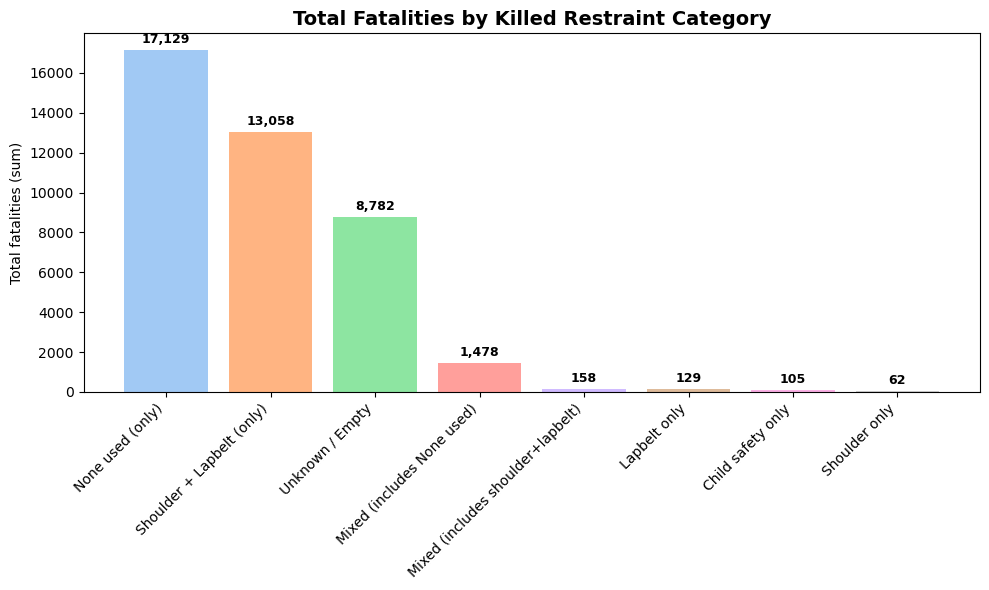

In [9]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def simplify_restraint(val):
    try:
        lst = ast.literal_eval(val)
        if not lst:
            return 'Unknown / Empty'
        lst = list(set(lst))
        if all(x == 'None_Used' for x in lst):
            return 'None used (only)'
        elif all(x == 'Shoulder_Lapbelt' for x in lst):
            return 'Shoulder + Lapbelt (only)'
        elif all(x == 'Lapbelt_Only' for x in lst):
            return 'Lapbelt only'
        elif all(x == 'Child_Safety' for x in lst):
            return 'Child safety only'
        elif all(x == 'Shoulder_Only' for x in lst):
            return 'Shoulder only'
        elif 'None_Used' in lst and len(lst) > 1:
            return 'Mixed (includes None used)'
        elif 'Shoulder_Lapbelt' in lst and len(lst) > 1:
            return 'Mixed (includes shoulder+lapbelt)'
        else:
            return 'Unknown / Empty'
    except:
        return 'Unknown / Empty'

data['Restraint_Category'] = data['Killed_Restraint_List'].apply(simplify_restraint)
agg = data.groupby('Restraint_Category')['Fatalities_Count'].sum().reset_index().sort_values('Fatalities_Count', ascending=False)

pastel_colors = sns.color_palette("pastel", len(agg))
plt.figure(figsize=(10,6))
bars = plt.bar(
    agg['Restraint_Category'],
    agg['Fatalities_Count'],
    color=pastel_colors
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 200,
        f'{int(height):,}',
        ha='center', va='bottom', fontsize=9, weight='bold'
    )

plt.title("Total Fatalities by Killed Restraint Category", fontsize=14, weight='bold')
plt.xlabel("")
plt.ylabel("Total fatalities (sum)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()